In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv('../data/WA_Fn-UseC_-HR-Employee-Attrition.csv')

# Basic info
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nData types:\n", df.dtypes)
print("\nMissing values:\n", df.isnull().sum().sum())
print("\nAttrition value counts:\n", df['Attrition'].value_counts())

Shape: (1470, 35)

Columns: ['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department', 'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount', 'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']

Data types:
 Age                         int64
Attrition                     str
BusinessTravel                str
DailyRate                   int64
Department                    str
DistanceFromHome            int64
Education                   int64
EducationField                str
EmployeeCount               int64
EmployeeNumber              int64

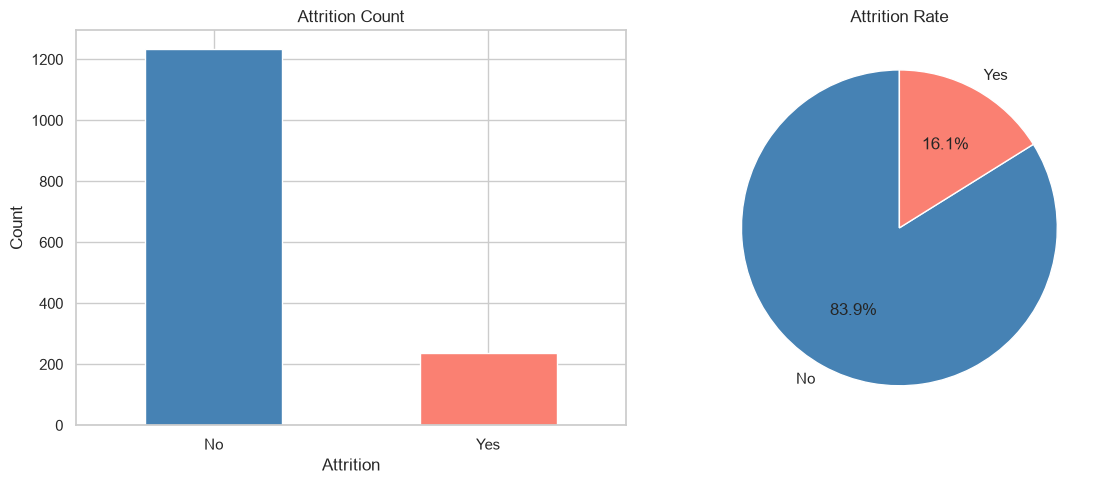

Attrition rate: 16.1 %


In [8]:
# Set style
sns.set_theme(style="whitegrid")

# 1. Overall attrition rate bar chart
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Count plot
df['Attrition'].value_counts().plot(kind='bar', ax=axes[0], color=['steelblue', 'salmon'])
axes[0].set_title('Attrition Count')
axes[0].set_xlabel('Attrition')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=0)

# Percentage pie chart
df['Attrition'].value_counts().plot(kind='pie', ax=axes[1], autopct='%1.1f%%',
                                     colors=['steelblue', 'salmon'], startangle=90)
axes[1].set_title('Attrition Rate')
axes[1].set_ylabel('')

plt.tight_layout()
plt.savefig('../screenshots/attrition_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print("Attrition rate:", round(237/1470*100, 1), "%")

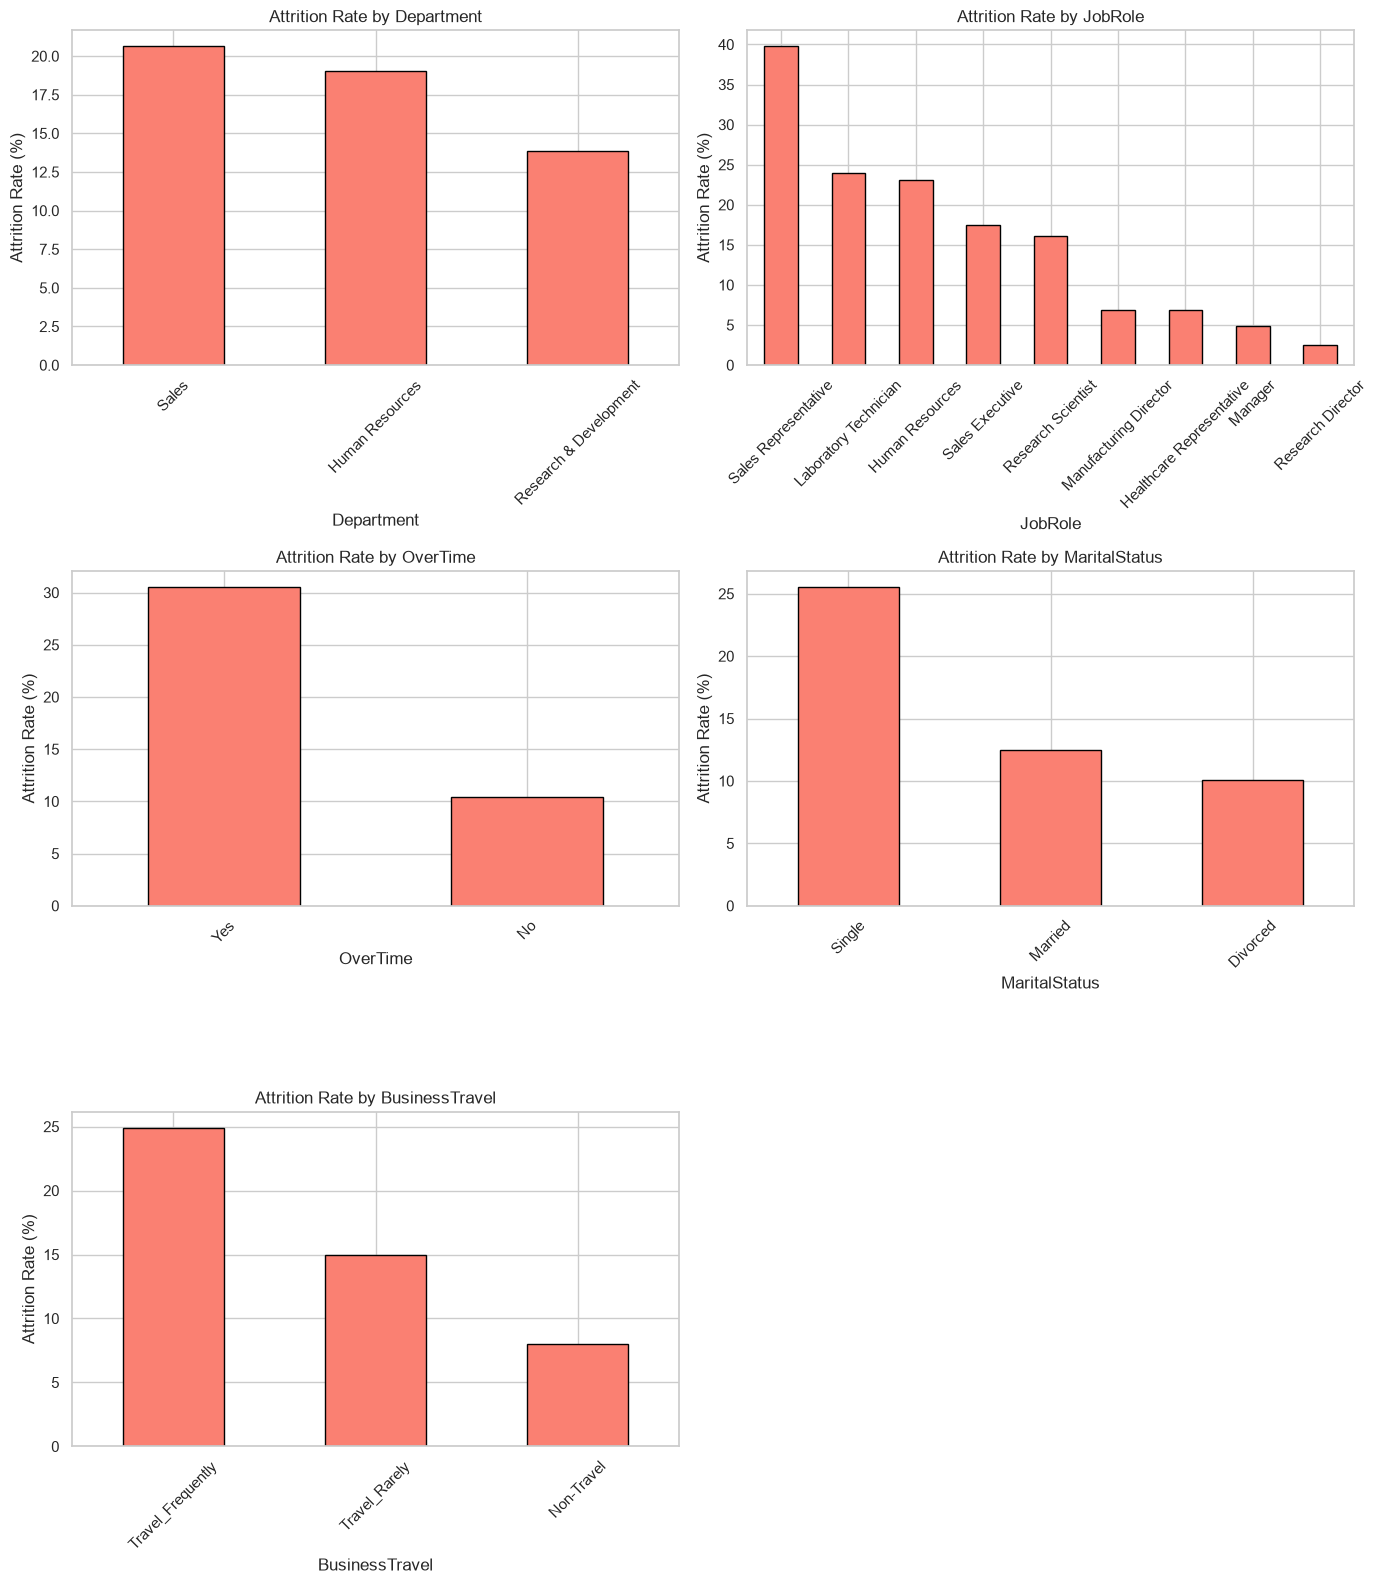

In [9]:
# Attrition rate by key categorical features
cat_cols = ['Department', 'JobRole', 'OverTime', 'MaritalStatus', 'BusinessTravel']

fig, axes = plt.subplots(3, 2, figsize=(14, 16))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    attrition_rate = df.groupby(col)['Attrition'].apply(
        lambda x: (x == 'Yes').sum() / len(x) * 100
    ).sort_values(ascending=False)
    
    attrition_rate.plot(kind='bar', ax=axes[i], color='salmon', edgecolor='black')
    axes[i].set_title(f'Attrition Rate by {col}')
    axes[i].set_ylabel('Attrition Rate (%)')
    axes[i].set_xlabel(col)
    axes[i].tick_params(axis='x', rotation=45)

# Hide the last empty subplot
axes[5].set_visible(False)

plt.tight_layout()
plt.savefig('../screenshots/attrition_by_category.png', dpi=150, bbox_inches='tight')
plt.show()

Attrition rates by Job Satisfaction and Work-Life Balance:
SatisfactionGroup  WLBGroup
High Satisfaction  High WLB    11.9
                   Low WLB     18.5
Low Satisfaction   High WLB    19.0
                   Low WLB     21.4
Name: Attrition, dtype: float64



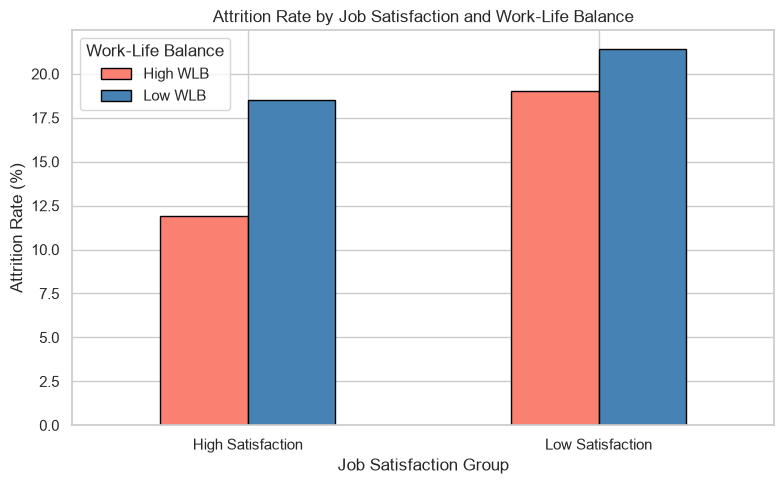

In [10]:
# Hypothesis: Work-life balance is an independent attrition driver
# Compare attrition rates across JobSatisfaction and WorkLifeBalance combinations

# High satisfaction = 3 or 4, Low satisfaction = 1 or 2
# Low work-life balance = 1 or 2, High work-life balance = 3 or 4

df['SatisfactionGroup'] = df['JobSatisfaction'].apply(
    lambda x: 'High Satisfaction' if x >= 3 else 'Low Satisfaction'
)
df['WLBGroup'] = df['WorkLifeBalance'].apply(
    lambda x: 'Low WLB' if x <= 2 else 'High WLB'
)

# Attrition rate by group combination
groups = df.groupby(['SatisfactionGroup', 'WLBGroup'])['Attrition'].apply(
    lambda x: (x == 'Yes').sum() / len(x) * 100
).round(1)

print("Attrition rates by Job Satisfaction and Work-Life Balance:")
print(groups)
print()

# Visualize
pivot = df.pivot_table(
    values='Attrition',
    index='SatisfactionGroup',
    columns='WLBGroup',
    aggfunc=lambda x: (x == 'Yes').sum() / len(x) * 100
).round(1)

fig, ax = plt.subplots(figsize=(8, 5))
pivot.plot(kind='bar', ax=ax, color=['salmon', 'steelblue'], edgecolor='black')
ax.set_title('Attrition Rate by Job Satisfaction and Work-Life Balance')
ax.set_ylabel('Attrition Rate (%)')
ax.set_xlabel('Job Satisfaction Group')
ax.tick_params(axis='x', rotation=0)
ax.legend(title='Work-Life Balance')

plt.tight_layout()
plt.savefig('../screenshots/hypothesis_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

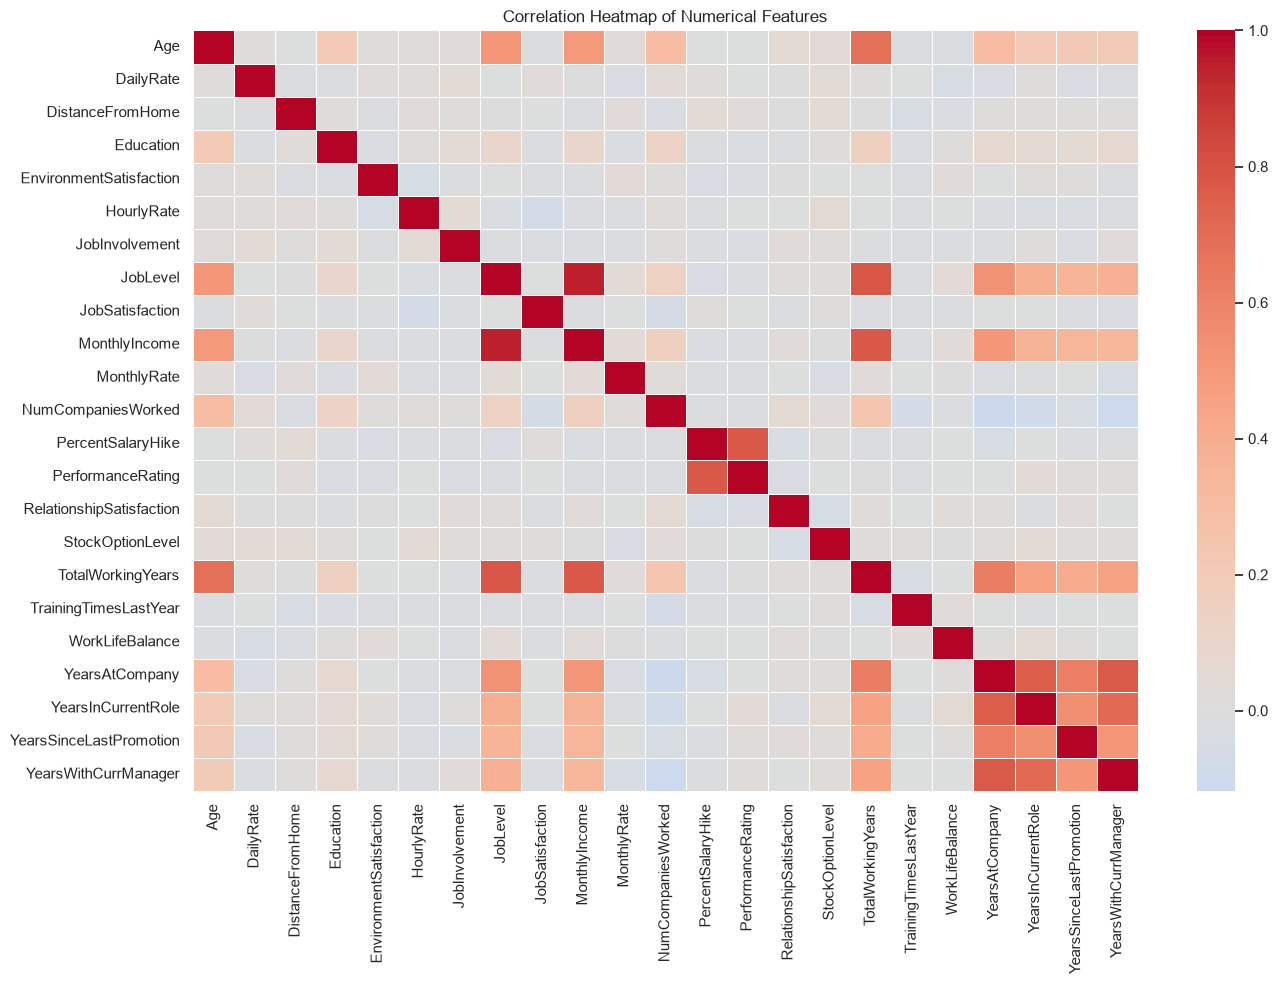

Remaining features: 31
Categorical columns: ['Attrition', 'BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'OverTime']


C:\Users\otero\AppData\Local\Temp\ipykernel_37804\29074181.py:18: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  print("Categorical columns:", df_model.select_dtypes(include='object').columns.tolist())


In [11]:
# Drop zero-variance columns
df_model = df.drop(columns=['EmployeeCount', 'StandardHours', 'Over18',
                              'EmployeeNumber', 'SatisfactionGroup', 'WLBGroup'])

# Correlation heatmap for numerical features
plt.figure(figsize=(14, 10))
numeric_cols = df_model.select_dtypes(include='number').columns
corr_matrix = df_model[numeric_cols].corr()

sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', center=0,
            linewidths=0.5, fmt='.2f')
plt.title('Correlation Heatmap of Numerical Features')
plt.tight_layout()
plt.savefig('../screenshots/correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print("Remaining features:", df_model.shape[1])
print("Categorical columns:", df_model.select_dtypes(include='object').columns.tolist())

In [12]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
import pickle

# Encode target variable
df_model['Attrition_Binary'] = (df_model['Attrition'] == 'Yes').astype(int)

# Encode categorical features
cat_cols = df_model.select_dtypes(include='object').columns.tolist()
cat_cols.remove('Attrition')

df_encoded = pd.get_dummies(df_model, columns=cat_cols)
df_encoded = df_encoded.drop(columns=['Attrition'])

# Features and target
X = df_encoded.drop(columns=['Attrition_Binary'])
y = df_encoded['Attrition_Binary']

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training set size:", X_train.shape)
print("Test set size:", X_test.shape)
print("Attrition rate in training set:", round(y_train.mean()*100, 1), "%")
print("Attrition rate in test set:", round(y_test.mean()*100, 1), "%")

# Train model
model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
model.fit(X_train, y_train)
print("\nModel trained successfully!")

C:\Users\otero\AppData\Local\Temp\ipykernel_37804\3355471241.py:11: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df_model.select_dtypes(include='object').columns.tolist()


Training set size: (1176, 51)
Test set size: (294, 51)
Attrition rate in training set: 16.2 %
Attrition rate in test set: 16.0 %

Model trained successfully!


MODEL EVALUATION RESULTS
Precision:  0.5000
Recall:     0.3830
F1 Score:   0.4337
ROC-AUC:    0.8007


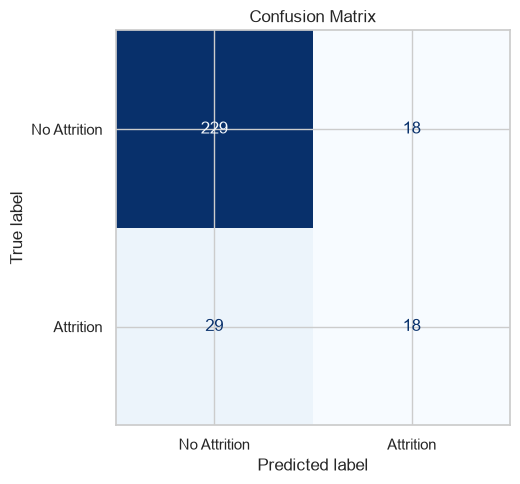

In [13]:
from sklearn.metrics import ConfusionMatrixDisplay
import numpy as np

# Predictions
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

# Metrics
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

print("=" * 40)
print("MODEL EVALUATION RESULTS")
print("=" * 40)
print(f"Precision:  {precision:.4f}")
print(f"Recall:     {recall:.4f}")
print(f"F1 Score:   {f1:.4f}")
print(f"ROC-AUC:    {roc_auc:.4f}")
print("=" * 40)

# Confusion matrix
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=ax,
                                         display_labels=['No Attrition', 'Attrition'],
                                         colorbar=False, cmap='Blues')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.savefig('../screenshots/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

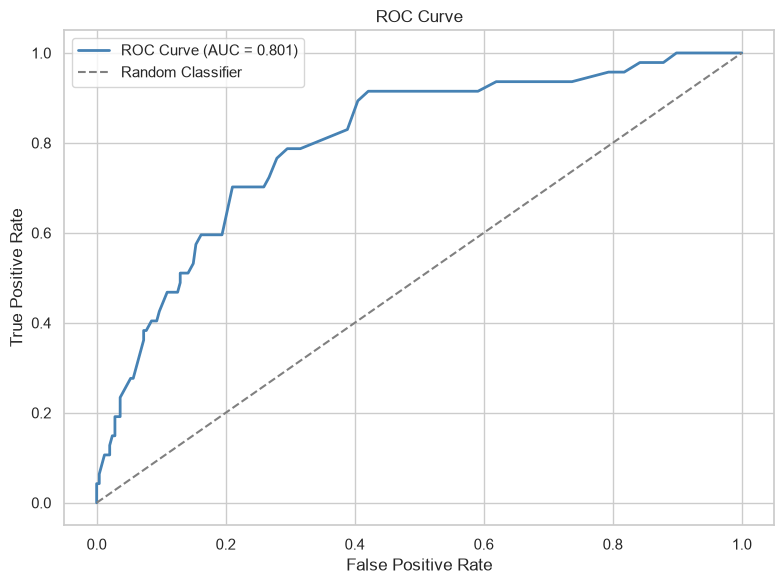

Best threshold: 0.30
Best F1 at that threshold: 0.4889

Tuned Results:
Precision:  0.3750
Recall:     0.7021
F1 Score:   0.4889
ROC-AUC:    0.8007


In [14]:
from sklearn.metrics import roc_curve

# Find the best threshold
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='steelblue', lw=2, label=f'ROC Curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.tight_layout()
plt.savefig('../screenshots/roc_curve.png', dpi=150, bbox_inches='tight')
plt.show()

# Try different thresholds and find best F1
best_f1 = 0
best_threshold = 0.5
for thresh in np.arange(0.1, 0.9, 0.05):
    preds = (y_prob >= thresh).astype(int)
    f = f1_score(y_test, preds)
    if f > best_f1:
        best_f1 = f
        best_threshold = thresh

print(f"Best threshold: {best_threshold:.2f}")
print(f"Best F1 at that threshold: {best_f1:.4f}")

# Apply best threshold
y_pred_tuned = (y_prob >= best_threshold).astype(int)
p_tuned = precision_score(y_test, y_pred_tuned)
r_tuned = recall_score(y_test, y_pred_tuned)
f1_tuned = f1_score(y_test, y_pred_tuned)

print(f"\nTuned Results:")
print(f"Precision:  {p_tuned:.4f}")
print(f"Recall:     {r_tuned:.4f}")
print(f"F1 Score:   {f1_tuned:.4f}")
print(f"ROC-AUC:    {roc_auc:.4f}")

In [15]:
# Try improved Random Forest with more trees and tuned parameters
model_v2 = RandomForestClassifier(
    n_estimators=500,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    class_weight='balanced'
)
model_v2.fit(X_train, y_train)

y_prob_v2 = model_v2.predict_proba(X_test)[:, 1]
roc_auc_v2 = roc_auc_score(y_test, y_prob_v2)

# Find best threshold for v2
best_f1_v2 = 0
best_thresh_v2 = 0.5
for thresh in np.arange(0.1, 0.9, 0.05):
    preds = (y_prob_v2 >= thresh).astype(int)
    f = f1_score(y_test, preds)
    if f > best_f1_v2:
        best_f1_v2 = f
        best_thresh_v2 = thresh

y_pred_v2 = (y_prob_v2 >= best_thresh_v2).astype(int)
p_v2 = precision_score(y_test, y_pred_v2)
r_v2 = recall_score(y_test, y_pred_v2)
f1_v2 = f1_score(y_test, y_pred_v2)

print("=" * 40)
print("IMPROVED MODEL RESULTS")
print("=" * 40)
print(f"Best threshold: {best_thresh_v2:.2f}")
print(f"Precision:  {p_v2:.4f}")
print(f"Recall:     {r_v2:.4f}")
print(f"F1 Score:   {f1_v2:.4f}")
print(f"ROC-AUC:    {roc_auc_v2:.4f}")

# Use whichever model is better
if f1_v2 > best_f1:
    print("\nUsing improved model (v2)")
    final_model = model_v2
    final_threshold = best_thresh_v2
    final_prob = y_prob_v2
else:
    print("\nKeeping original model")
    final_model = model
    final_threshold = best_threshold
    final_prob = y_prob

IMPROVED MODEL RESULTS
Best threshold: 0.45
Precision:  0.4667
Recall:     0.5957
F1 Score:   0.5234
ROC-AUC:    0.7929

Using improved model (v2)


Model saved successfully!

Top 21 Most Important Features:
                 Feature  Importance
           MonthlyIncome    0.076961
                     Age    0.062323
       TotalWorkingYears    0.058359
               DailyRate    0.048341
          YearsAtCompany    0.046326
    YearsWithCurrManager    0.040611
             MonthlyRate    0.038839
            OverTime_Yes    0.038257
        DistanceFromHome    0.037965
             OverTime_No    0.037785
              HourlyRate    0.037303
      NumCompaniesWorked    0.034958
        StockOptionLevel    0.034539
                JobLevel    0.028450
       PercentSalaryHike    0.026756
 EnvironmentSatisfaction    0.026616
      YearsInCurrentRole    0.026441
         JobSatisfaction    0.024841
 YearsSinceLastPromotion    0.020575
RelationshipSatisfaction    0.020270
         WorkLifeBalance    0.019481


C:\Users\otero\AppData\Local\Temp\ipykernel_37804\1550291198.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feat_imp, x='Importance', y='Feature', palette='coolwarm')


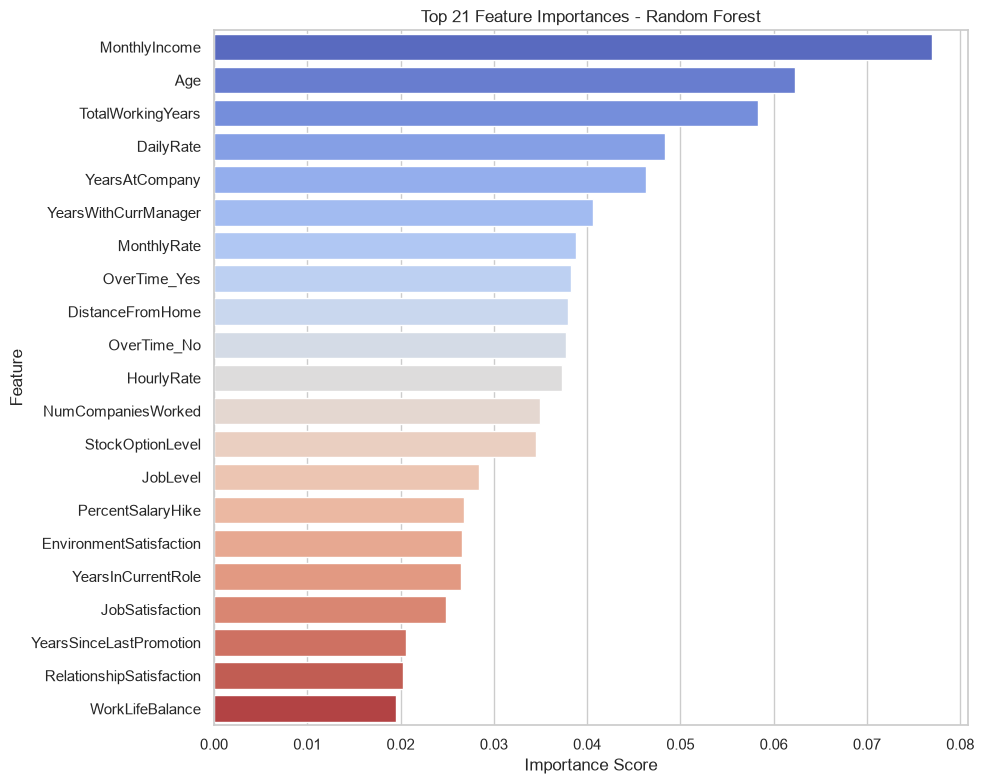

In [17]:
# Save the final model
with open('../model/model.pkl', 'wb') as f:
    pickle.dump(final_model, f)

with open('../model/threshold.pkl', 'wb') as f:
    pickle.dump(final_threshold, f)

with open('../model/feature_names.pkl', 'wb') as f:
    pickle.dump(X.columns.tolist(), f)

print("Model saved successfully!")

# Feature importance
importances = final_model.feature_importances_
feature_names = X.columns.tolist()
feat_imp = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values('Importance', ascending=False).head(21)

print("\nTop 21 Most Important Features:")
print(feat_imp.to_string(index=False))

# Plot
plt.figure(figsize=(10, 8))
sns.barplot(data=feat_imp, x='Importance', y='Feature', palette='coolwarm')
plt.title('Top 21 Feature Importances - Random Forest')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('../screenshots/feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

In [18]:
# Find WorkLifeBalance rank
all_feat_imp = pd.DataFrame({
    'Feature': feature_names,
    'Importance': final_model.feature_importances_
}).sort_values('Importance', ascending=False).reset_index(drop=True)

wlb_rank = all_feat_imp[all_feat_imp['Feature'] == 'WorkLifeBalance'].index[0] + 1
wlb_score = all_feat_imp[all_feat_imp['Feature'] == 'WorkLifeBalance']['Importance'].values[0]
js_rank = all_feat_imp[all_feat_imp['Feature'] == 'JobSatisfaction'].index[0] + 1
js_score = all_feat_imp[all_feat_imp['Feature'] == 'JobSatisfaction']['Importance'].values[0]

print(f"WorkLifeBalance rank: #{wlb_rank}, importance: {wlb_score:.4f}")
print(f"JobSatisfaction rank: #{js_rank}, importance: {js_score:.4f}")
print(f"\nTotal features: {len(all_feat_imp)}")

WorkLifeBalance rank: #21, importance: 0.0195
JobSatisfaction rank: #18, importance: 0.0248

Total features: 51


In [20]:
slice_cols = ['Department', 'Gender', 'MaritalStatus', 'EducationField', 'JobRole']

results = []
with open('../slice_output.txt', 'w') as outfile:
    for col in slice_cols:
        for val in df[col].unique():
            mask = df.iloc[X_test.index][col] == val
            if mask.sum() < 10:
                continue
            
            X_slice = X_test[mask]
            y_slice = y_test[mask]
            y_prob_slice = final_model.predict_proba(X_slice)[:, 1]
            y_pred_slice = (y_prob_slice >= final_threshold).astype(int)
            
            if y_slice.sum() == 0:
                continue
                
            p = precision_score(y_slice, y_pred_slice, zero_division=0)
            r = recall_score(y_slice, y_pred_slice, zero_division=0)
            f1_s = f1_score(y_slice, y_pred_slice, zero_division=0)
            
            line = f"{col}: {val} | Count: {len(y_slice)} | Attrition: {y_slice.sum()} | P: {p:.2f} | R: {r:.2f} | F1: {f1_s:.2f}"
            print(line)
            outfile.write(line + '\n')
            results.append({'Feature': col, 'Value': val, 'Count': len(y_slice),
                           'Precision': p, 'Recall': r, 'F1': f1_s})

print("\nSlice output saved to slice_output.txt")

Department: Sales | Count: 82 | Attrition: 16 | P: 0.57 | R: 0.81 | F1: 0.67
Department: Research & Development | Count: 197 | Attrition: 29 | P: 0.40 | R: 0.48 | F1: 0.44
Department: Human Resources | Count: 15 | Attrition: 2 | P: 0.50 | R: 0.50 | F1: 0.50
Gender: Female | Count: 116 | Attrition: 16 | P: 0.34 | R: 0.62 | F1: 0.44
Gender: Male | Count: 178 | Attrition: 31 | P: 0.58 | R: 0.58 | F1: 0.58
MaritalStatus: Single | Count: 97 | Attrition: 25 | P: 0.58 | R: 0.72 | F1: 0.64
MaritalStatus: Married | Count: 133 | Attrition: 18 | P: 0.42 | R: 0.44 | F1: 0.43
MaritalStatus: Divorced | Count: 64 | Attrition: 4 | P: 0.20 | R: 0.50 | F1: 0.29
EducationField: Life Sciences | Count: 127 | Attrition: 14 | P: 0.36 | R: 0.57 | F1: 0.44
EducationField: Other | Count: 20 | Attrition: 6 | P: 0.86 | R: 1.00 | F1: 0.92
EducationField: Medical | Count: 100 | Attrition: 14 | P: 0.42 | R: 0.57 | F1: 0.48
EducationField: Marketing | Count: 25 | Attrition: 6 | P: 0.71 | R: 0.83 | F1: 0.77
EducationF